In [12]:
import numpy as np
import timeit
import pandas as pd
from typing import NamedTuple, List, Tuple
from IPython.display import display
from shapely.geometry import Point, Polygon
from shapely.geometry.polygon import Polygon as ShapelyPolygon
import sys
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML
# Add measurement mcts python package to path
sys.path.append('../src/measurement_mcts')
from measurement_mcts.environment.measurement_control_env import MeasurementControlEnvironment
from measurement_mcts.utils.utils import wrap_angle, min_max_normalize, rotate_about_point

Toy Measurement Control Initialized


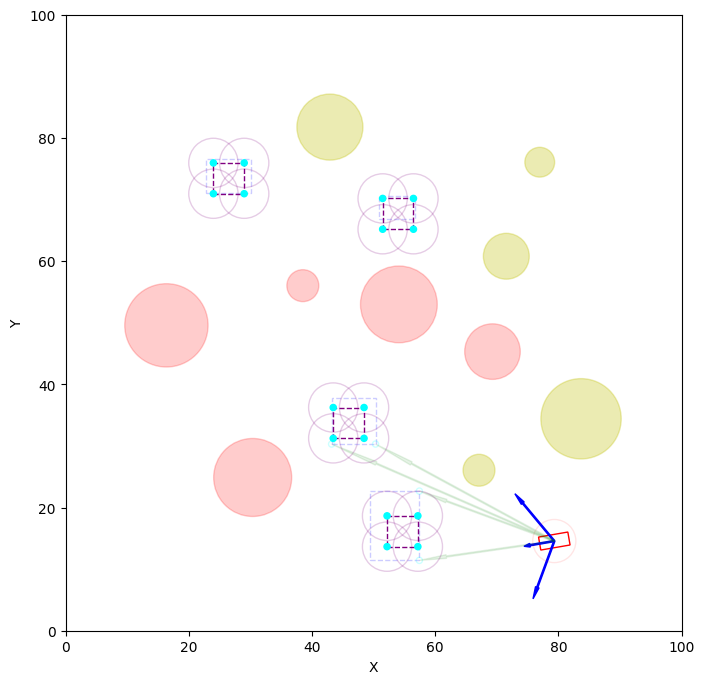

In [14]:
env = MeasurementControlEnvironment()
state = env.reset()
env.draw_state(state)

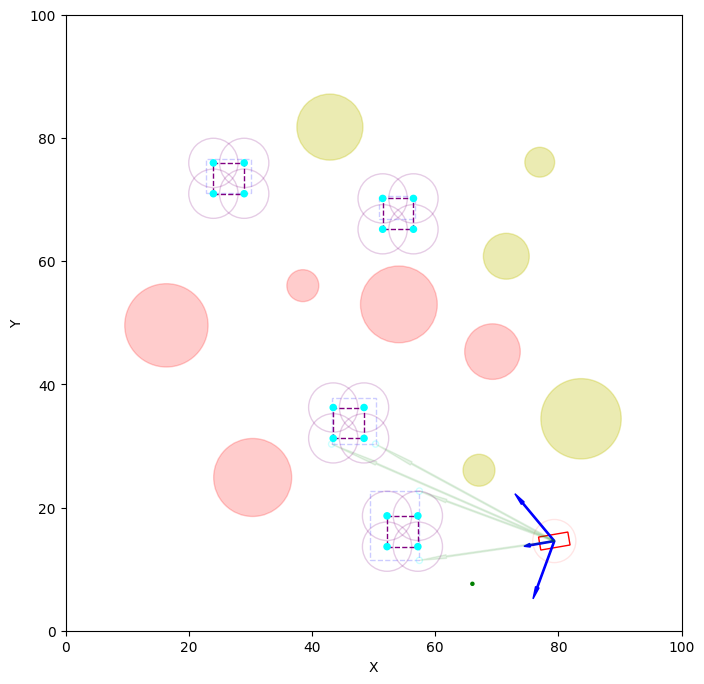

In [ ]:
def get_hertg_target_point(state, env, dist_weight=0.1, bearing_weight=1, lookahead_distance=15, ooi_circle_space=15, ui=None):
    # Pull out state elements
    car_state, ooi_means, ooi_covs, horizon = state
    car_pos, car_yaw = car_state[:2], car_state[3]
    
    # Compute centers of each ooi and their range and bearing to the car
    ooi_centers = np.mean(ooi_means, axis=1)
    car_to_center_dists = np.linalg.norm(ooi_centers - car_pos, axis=1)
    car_to_center_bearings = np.abs(wrap_angle(np.arctan2(ooi_centers[:, 1] - car_pos[1], ooi_centers[:, 0] - car_pos[0]) - car_yaw))
    
    # Compute covariance trace sums for each ooi and normalize
    ooi_trace_sums = np.sum(np.trace(ooi_covs, axis1=2, axis2=3), axis=1)
    norm_ooi_trace_sums = min_max_normalize(ooi_trace_sums, 0, env.init_covariance_trace/4)
    
    # Compute cost for each ooi
    ooi_cost = norm_ooi_trace_sums * (dist_weight * car_to_center_dists + bearing_weight * car_to_center_bearings)
    
    # Pick the lowest cost ooi as the best one
    best_ooi_idx = np.argmin(ooi_cost)
    
    # Project the target point from car to best ooi
    best_ooi_center = ooi_centers[best_ooi_idx]
    car_to_ooi = best_ooi_center - car_pos
    car_to_ooi_norm = np.linalg.norm(car_to_ooi)
    unit_car_to_ooi = car_to_ooi / car_to_ooi_norm
    
    # Cap the lookahead distance to the distance to the best ooi
    lookahead_distance = min(lookahead_distance, car_to_ooi_norm)
    target_point = car_pos + lookahead_distance * unit_car_to_ooi
    
    # Check if the target point is near an ooi circle
    target_point_near_ooi = np.linalg.norm(target_point - ooi_centers, axis=1) < ooi_circle_space
    
    # Get indices where true
    near_ooi_indices = np.where(target_point_near_ooi)[0]
    
    if len(near_ooi_indices) > 1:
        raise ValueError('Multiple OOIs near target point')
    elif len(near_ooi_indices) == 1:
        # Rotate target point around car to avoid ooi
        angle = np.abs(np.arctan2(ooi_circle_space, car_to_center_dists[near_ooi_indices[0]]))
        
        # Pick direction based on car heading relative to ooi
        car_to_close_ooi = ooi_centers[near_ooi_indices[0]] - car_pos
        car_to_ooi_angle = np.arctan2(car_to_close_ooi[1], car_to_close_ooi[0])
        print(f'Car to ooi angle: {np.degrees(car_to_ooi_angle)}, Car yaw: {np.degrees(car_yaw)}')
        if car_yaw > car_to_ooi_angle:
            angle = -angle
        
        # Rotate target point around car
        target_point = rotate_about_point(target_point, angle, car_pos)
        
        if ui is not None:
            ui.draw_point(target_point, 'green', radius=0.25)
            
        return target_point
    
    # Now check if the target point is inside an obstacle/occlusion
    obs_means = np.vstack((env.object_manager.obstacle_means, env.object_manager.occlusion_means))
    obs_radii = np.hstack((env.object_manager.obstacle_radii, env.object_manager.occlusion_radii))
    target_point_to_obs_dists = np.linalg.norm(target_point - obs_means, axis=1)
    target_point_inside_obs = target_point_to_obs_dists < obs_radii + env.car_collision_radius
    collision_indices = np.where(target_point_inside_obs)[0]
    
    if len(collision_indices) > 1:
        raise ValueError('Multiple obstacles/occlusions near target point')
    elif len(collision_indices) == 1:
        # Rotate target point around car to avoid obstacle
        car_to_obs_dist = np.linalg.norm(obs_means[collision_indices[0]] - car_pos)
        angle = np.abs(np.arctan2(obs_radii[collision_indices[0]] + env.car_collision_radius, car_to_obs_dist))
        
        # Pick direction based on target_point heading relative to obstacle
        car_to_close_obs = obs_means[collision_indices[0]] - car_pos
        car_to_obs_angle = np.arctan2(car_to_close_obs[1], car_to_close_obs[0])
        car_to_target_point = target_point - car_pos
        car_to_target_point_angle = np.arctan2(car_to_target_point[1], car_to_target_point[0])
        if car_to_target_point_angle < car_to_obs_angle:
            angle = -angle
        
        # Rotate target point around car
        target_point = rotate_about_point(target_point, angle, car_pos)
        
        if ui is not None:
            ui.draw_point(target_point, 'green', radius=0.25)
            
        return target_point

    if ui is not None:
        ui.draw_point(target_point, 'green', radius=0.25)
        
    return target_point

get_hertg_target_point(state, env, ui=env.ui)

env.draw_state(state)

In [16]:
def get_target_point_follow_action(car_state, env, target_point, no_turn_degrees=10, max_turn_degrees=20):
    car_pos = car_state[:2]
    car_yaw = car_state[3]
    steering_options = env.steering_acc_options[2:] # Take the 0 and positive options
    
    # Compute vector from car to target point
    car_to_target_point = target_point - car_pos
    car_to_target_point_angle = np.arctan2(car_to_target_point[1], car_to_target_point[0])
    
    # Compute angle difference between car heading and target point
    angle_diff = wrap_angle(car_to_target_point_angle - car_yaw)
    angle_sign = np.sign(angle_diff)
    
    # Determine action based on angle difference
    if np.abs(angle_diff) < np.radians(no_turn_degrees):
        return [1, steering_options[0]]                 # Accelerate, no turning
    elif np.abs(angle_diff) < np.radians(max_turn_degrees):
        return [1, angle_sign * steering_options[1]]    # Accelerate, turn slightly
    else:
        return [1, angle_sign * steering_options[2]]    # Accelerate, turn max
    
target_point = get_hertg_target_point(state, env)
get_target_point_follow_action(state[0], env, target_point)

[1, 0.25]

In [39]:
def animate(i):
    global state, observation, ax
    
    # Clear all existing patches from the axis
    for patch in ax.patches:
        patch.remove()
    print(f'Frame: {i}')
    env.draw_state(state, observation=observation, plot=False)
    target_point = get_hertg_target_point(state, env, ui=env.ui)
    action = get_target_point_follow_action(state[0], env, target_point)
    state, reward, done, observation = env.step(state, action, return_observation=True)
    
    # Add artists to the axis
    for artist in env.ui.get_artists():
        ax.add_patch(artist)
    
    return ax.patches
    
state = env.get_state()
observation = None


# Get the figure and axis from the UI
fig, ax = env.ui.plot(get_fig_ax=True)
plt.close()

ani = FuncAnimation(fig, animate, frames=100, interval=200, blit=False)
    
# Display the animation in the notebook
display(HTML(ani.to_jshtml()))

Frame: 0
Frame: 0
Frame: 1
Frame: 2
Frame: 3
Frame: 4
Frame: 5
Frame: 6
Frame: 7
Frame: 8
Frame: 9
Frame: 10
Frame: 11
Frame: 12
Frame: 13
Frame: 14
Frame: 15
Frame: 16
Frame: 17
Frame: 18
Frame: 19
Frame: 20
Frame: 21
Frame: 22
Frame: 23
Frame: 24
Frame: 25
Frame: 26
Frame: 27
Frame: 28
Frame: 29
Frame: 30
Frame: 31
Frame: 32
Frame: 33
Frame: 34
Frame: 35
Frame: 36
Frame: 37
Frame: 38
Frame: 39
Frame: 40
Frame: 41
Frame: 42
Frame: 43
Frame: 44
Frame: 45
Frame: 46
Frame: 47
Frame: 48
Frame: 49
Frame: 50
Frame: 51
Frame: 52
Frame: 53
Frame: 54
Frame: 55
Frame: 56
Frame: 57
Frame: 58
Frame: 59
Frame: 60
Frame: 61
Frame: 62
Frame: 63
Frame: 64
Frame: 65
Frame: 66
Frame: 67
Frame: 68
Frame: 69
Frame: 70
Frame: 71
Frame: 72
Frame: 73
Frame: 74
Frame: 75
Frame: 76
Frame: 77
Frame: 78
Frame: 79
Frame: 80
Frame: 81
Frame: 82
Frame: 83
Frame: 84
Frame: 85
Frame: 86
Frame: 87
Frame: 88
Frame: 89
Frame: 90
Frame: 91
Frame: 92
Frame: 93
Frame: 94
Frame: 95
Frame: 96
Frame: 97
Frame: 98
Frame: 99
